![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/05/logo-upv-horizontal.png)
![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/06/logos-perte-chip-1024x119.png)


# Laboratory 1. Waveguides

Welcome to our Photonic Integrated Circuits Laboratory! Throughout the course, we will be using a Python package called [GDSFactory](https://gdsfactory.github.io/gdsfactory/index.html). This is an open-source tool, and is a great alternative to other commercial software like Synopsys Optodesigner, Luceda Photonics, or Lumerical/Interconnect. Since it runs on Python, you have two options for executing your laboratory tasks:

1. **Local installation on your own PC** (Recommended): Please note that we will not spend class time on installing the software. However, feel free to reach out if you need help with the installation.

2. **Cloud Workspace**: Alternatively, you can use a cloud-based solution if the Local installation does not work.

## 0. Imports

For this laboratory you will need the following libraries:

In [2]:
import matplotlib.pyplot as plt
import numpy as np

import tidy3d as td

import gplugins as gp
import gplugins.tidy3d as gt
from gplugins import plot
from gplugins.common.config import PATH

nm = 1e-3
wavelength = np.linspace(1500, 1600,11) * nm
f = td.C_0 / wavelength


In [3]:
nitride_complex = td.material_library["Si3N4"]["Luke2015PMLStable"].eps_model(f)
nitride_index, nitride_k = td.Medium.eps_complex_to_nk(nitride_complex)
box_complex = td.material_library["SiO2"]["Horiba"].eps_model(f)
box_index, box_k = td.Medium.eps_complex_to_nk(box_complex)

## LO.1. Effective index of a waveguide

### Convergence Tests
We have asumed until now, that the **real** value of the effective index for each cross-section is the value provided by this mode-solver. However, this number relies on a numerical method, making it sensible to some input parameters, such as the selected grid. The objective of this section is to find the dependence of the **calculated** value of the effective index with the *grid_resolution* and the *max_grid_scaling*, the two parameters that we can modify from the automatic grid function used at the gt.modes.Waveguide() function.  <br>
- Consider a 1.2 um width deep waveguide (SiNx), with 0.3 um height operating at 1550 nm.
    - Sweep the *grid_resolution* between 10 and 100 in steps of 10. Plot the **calculated** effective index vs the *grid_resolution*. 
    - Select a value for the *grid_resolution* from the latter sweep (where the calculated index remains almost constant), and sweep the *max_grid_scaling* from 1.2 to 1.6 in steps of 0.1. Plot the **calculated** effective index vs the *max_grid_scaling*.
    - Conclude which will be the best configuration for the grid parameters for this particular case. 

Ver si es constante o no


2026-03-03 16:07:31.057 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_cf92515ae4232c65.npz.


array([1.60524792, 1.52829803, 1.45072999, 1.43325817])

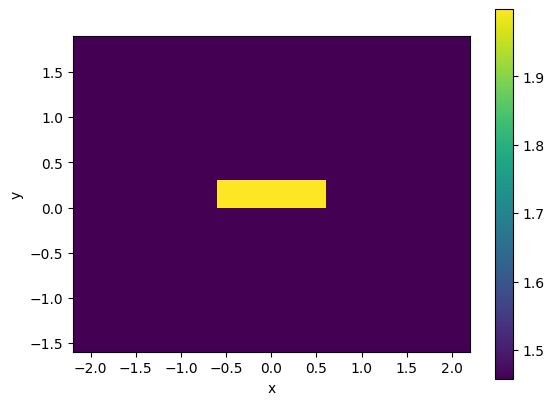

In [4]:
deep_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=1.2, # Waveguide width
    core_thickness=300 * nm, # Waveguide height 
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=1550 * nm, # Wavelength to simulate
    num_modes=4, # Targeted number of modes to find 
    max_grid_scaling=1.5, # Parameters of the grid 
    grid_resolution=20, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
)

deep_waveguide.plot_index()

deep_waveguide.n_eff.real

# Student continue your code here ...

2026-03-03 16:07:31.781 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_13fe960528db7e9b.npz.
2026-03-03 16:07:31.802 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_cf92515ae4232c65.npz.
2026-03-03 16:07:31.802 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_152975b7cd7bd92b.npz.
2026-03-03 16:07:31.830 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_721700b7522a7617.npz.
2026-03-03 16:07:31.851 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_0ea6c3bb3b1c00e8.npz.
2026-03-03 16:07:31.869 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_67a04e2475ce3436.npz.
2026-03-03 16:07:31.879 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_b110164ae7f9a70a.npz.
2026-03-03 16:07:31.895 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_c8d8b6bf9be8a3e8.npz.


Text(0, 0.5, 'Effective index')

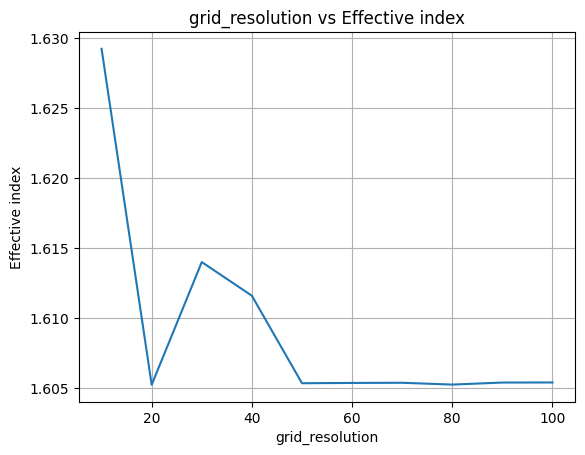

In [5]:
grid_resolution_list = np.linspace(10, 100, 10)
index_list = []
for i in grid_resolution_list:

    deep_waveguide = gt.modes.Waveguide(
        # Geometrical Parameters
        core_width=1.2, # Waveguide width
        core_thickness=300 * nm, # Waveguide height 
        slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
        # Materials
        core_material='sin', #  Material of the waveguide
        clad_material='sio2', # Surrounding material
        # Modesolver Parameters
        wavelength=1550 * nm, # Wavelength to simulate
        num_modes=4, # Targeted number of modes to find 
        max_grid_scaling=1.5, # Parameters of the grid 
        grid_resolution= i, # Parameters of the grid
        cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
        precision='double',
    )

    index_list.append(deep_waveguide.n_eff.real[0])

index_list = np.array(index_list)

plt.plot(grid_resolution_list, index_list)
plt.grid()
plt.title('grid_resolution vs Effective index')
plt.xlabel('grid_resolution')
plt.ylabel('Effective index')

Si observamos la primera gráfica, vemos que el valor del índice efectivo se estabiliza para valores de grid resolution mayores a 50.
Para crear la gráfica para el caso de análisis de max_grid_scaling en vez de usar un valor de grid resolution mayor a 50, se ha optado por usar de 20, ya que para este valor se obtiene un índice efectivo equivalente al del caso de estabilidad para valores mayores a 50 en el grid resolution, y con ello tendremos un menor coste computacional.

2026-03-03 16:07:32.139 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_29761b037c0c9026.npz.
2026-03-03 16:07:32.148 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_fbe312fd02002ae4.npz.
2026-03-03 16:07:32.168 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_76e2764f504071ba.npz.
2026-03-03 16:07:32.187 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_cf92515ae4232c65.npz.
2026-03-03 16:07:32.198 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_683206c3f01233c4.npz.


Text(0, 0.5, 'Effective index')

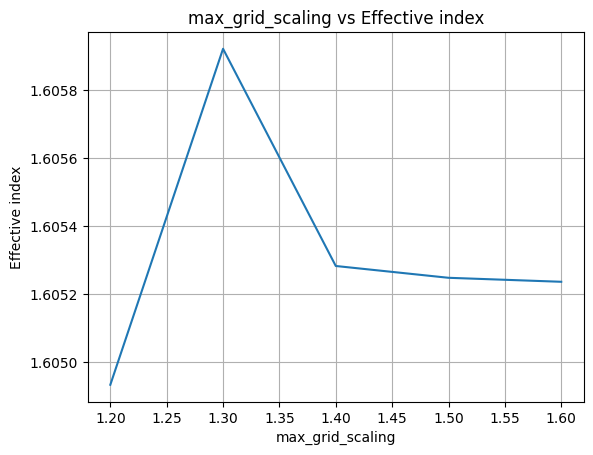

In [6]:
max_grid_scaling_list = np.linspace(1.2, 1.6, 5)
index_list = []
for i in max_grid_scaling_list:

    deep_waveguide = gt.modes.Waveguide(
        # Geometrical Parameters
        core_width=1.2, # Waveguide width
        core_thickness=300 * nm, # Waveguide height 
        slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
        # Materials
        core_material='sin', #  Material of the waveguide
        clad_material='sio2', # Surrounding material
        # Modesolver Parameters
        wavelength=1550 * nm, # Wavelength to simulate
        num_modes=4, # Targeted number of modes to find 
        max_grid_scaling=i, # Parameters of the grid 
        grid_resolution= 20, # Parameters of the grid
        cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
        precision='double',
    )

    index_list.append(deep_waveguide.n_eff.real[0])

index_list = np.array(index_list)

plt.plot(max_grid_scaling_list, index_list)
plt.grid()
plt.title('max_grid_scaling vs Effective index')
plt.xlabel('max_grid_scaling')
plt.ylabel('Effective index')

Finalmente, podemos concluir que para valores del grid resolution mayores de 50 y valores de max grid scaling mayores de 1.5 se obtienen valores estables del índice efectivo.

## LO.2. Width dependence

- Perform a sweep of the **deep** waveguide width. Use the code provided in the following cell or program your own sweep. 

Ver si usamos el ancho de guía como parámetro

  0%|          | 0/11 [00:00<?, ?it/s]

2026-03-03 16:07:32.434 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_e0f2a62752cad497.npz.
2026-03-03 16:07:32.456 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_cad20f99025f789a.npz.
2026-03-03 16:07:32.477 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_575965d134f345c4.npz.
2026-03-03 16:07:32.498 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_3ca61e62fe85ccf2.npz.
2026-03-03 16:07:32.513 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_8b617c8aef408673.npz.
2026-03-03 16:07:32.529 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_cd84020834745298.npz.
2026-03-03 16:07:32.576 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_df7667b1ace5cc7e.npz.
2026-03-03 16:07:32.591 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_a4e198a34f8f1987.npz.


  0%|          | 0/11 [00:00<?, ?it/s]

2026-03-03 16:07:32.693 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_e0f2a62752cad497.npz.
2026-03-03 16:07:32.699 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_cad20f99025f789a.npz.
2026-03-03 16:07:32.704 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_575965d134f345c4.npz.
2026-03-03 16:07:32.710 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_3ca61e62fe85ccf2.npz.
2026-03-03 16:07:32.718 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_8b617c8aef408673.npz.
2026-03-03 16:07:32.724 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_cd84020834745298.npz.
2026-03-03 16:07:32.730 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_df7667b1ace5cc7e.npz.
2026-03-03 16:07:32.736 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_a4e198a34f8f1987.npz.


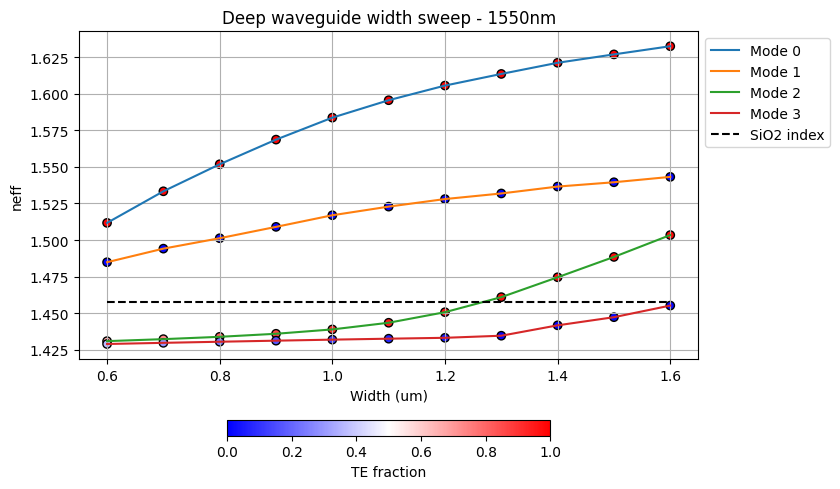

In [7]:
wavelength = 1.55 # Student code here

deep_waveguide = gt.modes.Waveguide(
    wavelength=wavelength,
    core_width=1.2,
    core_material='sin',
    clad_material='sio2',
    core_thickness=300 * nm,
    slab_thickness=0 * nm,
    num_modes=4,
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.2,
    grid_resolution=20, 
)

w = np.linspace(0.6, 1.6, 11) # Student code here

sweep_neff = gt.modes.sweep_n_eff(deep_waveguide, 
                             core_width=w)

sweep_tefraction = gt.modes.sweep_fraction_te(deep_waveguide,
                                              core_width=w)

plt.figure(figsize=(10, 5))
for k in range(sweep_neff.shape[1]):
    plt.scatter(w, sweep_neff[:,k].real,edgecolors='k',c=sweep_tefraction.sel(mode_index=k),vmin=0, vmax=1,label = '__nolegend__',cmap='bwr')
    plt.plot(w, sweep_neff[:,k].real,label=f'Mode {k}')

plt.title("Deep waveguide width sweep - 1550nm")
plt.xlabel("Width (um)")
plt.ylabel("neff")
plt.grid()
plt.hlines(np.mean(box_index), xmin=np.min(w), xmax=np.max(w), colors='k', linestyles='dashed',label='SiO2 index')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.colorbar(orientation='horizontal',fraction=0.04).set_label("TE fraction")

## LO.3. Waveguide compact model

El Compact model es una ecuación con una serie de parametros que permite modelar el comportamiendo de un modo propagandose por una guía de onda. Modela la propagación en amplitud y fase.

El comportamiento del índice efectivo respecto a lambda se puede obtener de una función de la práctica anterior. Índice efectivo para el Modo TE y para el TM para guías de onda shallow y deep. En total 4 modelos.

Hacemos un polifit para hallar el n_eff(lambda). n3 modifica el comportamiento de segundo orden.
D es la dispersión. Se usa para hallar la n3

Un índice de grupo alto indica una alta variavilidad en 

A compact model of an integrated photonic waveguide is a reduced-order mathematical model that describes the waveguide’s optical behavior—such as phase propagation, loss, and dispersion, using analytical or semi-analytical equations. Consider: 

Transfer function for propagation in a waveguide:

$$
H(\lambda)
= e^{-j\,\beta(\lambda)\,z}
= e^{-j\,\mathrm{Re}\{\beta(\lambda)\}\,z}\,
  e^{\mathrm{Im}\{\beta(\lambda)\}\,z}.
$$

Where 

$$
\beta(\lambda)
= \frac{2\pi}{\lambda}\,\mathrm{Re}\{n_\mathrm{eff}(\lambda)\}.
$$

Let's model the waveguide's effective index wavelength variation using a second order polynomial:

$$
n_\mathrm{eff}(\lambda)
= n_{1} + n_{2}\,(\lambda-\lambda_{0}) + n_{3}\,(\lambda-\lambda_{0})^{2}
$$

Where 

1. 
$$
n_\mathrm{eff}(\lambda_0) = n_1
$$
2. 
$$
n_g(\lambda_0) = n_1 - n_2\,\lambda_0
$$
3. 
$$
D = -\frac{2\,\lambda_0\,n_3}{c}\;\;[\mathrm{s}^2/\mathrm{m}]
$$

- Find the **compact models** of the following waveguides: 
    - Deep waveguide, height = 300nm, width = 1.2um 
    - Shallow waveguide, core height = 300nm, slab height = 150 nm, width = 1.2um 

**TIP**. Use the Lab0.1.Modesolver results (neff vs lambda) as starting point. Fit the results using a second order polynomial (with the lambda_0 shift) and relate the fit results to n_g and D values.

### Deep waveguide

/home/andriusstb/pic-upv-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/andriusstb/pic-upv-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/andriusstb/pic-upv-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/

19:38:12 CEST WARNING: The group index was not computed. To calculate group     
              index, pass 'group_index_step = True' in the 'ModeSpec'.          

2026-10-01 19:38:12.532 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_1afa5c5a3bf6c9a5.npz.


/home/andriusstb/pic-upv-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/andriusstb/pic-upv-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/andriusstb/pic-upv-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/

19:38:59 CEST WARNING: Mode field at frequency index 2, mode index 1 does not   
              decay at the plane boundaries.                                    

...

19:39:00 CEST WARNING: Mode field at frequency index 7, mode index 1 does not   
              decay at the plane boundaries.                                    

              WARNING: Mode field at frequency index 8, mode index 1 does not   
              decay at the plane boundaries.                                    

              WARNING: Mode field at frequency index 9, mode index 1 does not   
              decay at the plane boundaries.                                    

              WARNING: Mode field at frequency index 10, mode index 1 does not  
              decay at the plane boundaries.                                    

2026-10-01 19:39:00.149 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_346e3d2a7f06fcd6.npz.

  DEEP-ETCHED STRIP WAVEGUIDE
[TE0 Mode]
  n1 (n_eff at 1.55 µm) : 1.6054
  n2 (dn_eff/dλ)        : -0.2161 µm⁻¹
  n3 (0.5 * d²n/dλ²)    : 0.0962 µm⁻²
  Group index (n_g)     : 1.9403
  Dispersion D (SI)     : -9.949e-04 s/m²
  Dispersion D          : -994.92 ps/(nm·km)

[TM0 Mode]
  n1 (n_eff at 1.55 µm) : 1.5277
  n2 (dn_eff/dλ)        : -0.1573 µm⁻¹
  n3 (0.5 * d²n/dλ²)    : 0.1526 µm⁻²
  Group index (n_g)     : 1.7716
  Dispersion D (SI)     : -1.578e-03 s/m²
  Dispersion D          : -1578.01 ps/(nm·km)



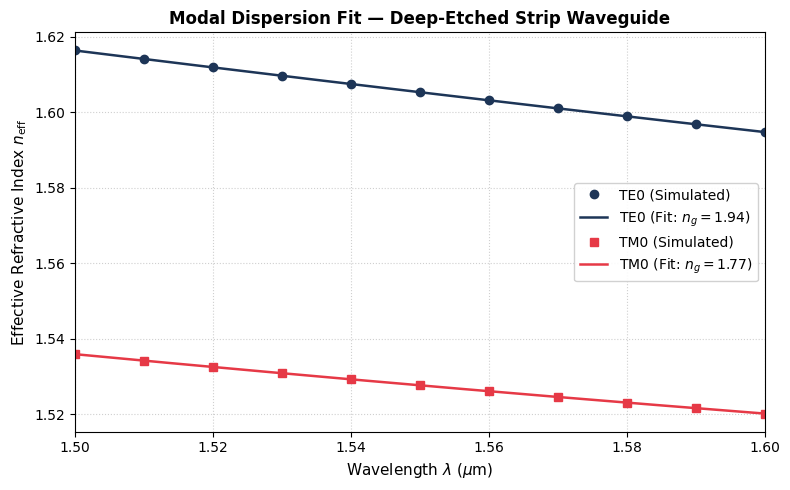


  SHALLOW-ETCHED RIB WAVEGUIDE
[TE0 Mode]
  n1 (n_eff at 1.55 µm) : 1.6288
  n2 (dn_eff/dλ)        : -0.1888 µm⁻¹
  n3 (0.5 * d²n/dλ²)    : 0.0934 µm⁻²
  Group index (n_g)     : 1.9214
  Dispersion D (SI)     : -9.663e-04 s/m²
  Dispersion D          : -966.28 ps/(nm·km)

[TM0 Mode]
  n1 (n_eff at 1.55 µm) : 1.5463
  n2 (dn_eff/dλ)        : -0.1313 µm⁻¹
  n3 (0.5 * d²n/dλ²)    : 0.1226 µm⁻²
  Group index (n_g)     : 1.7499
  Dispersion D (SI)     : -1.268e-03 s/m²
  Dispersion D          : -1268.17 ps/(nm·km)



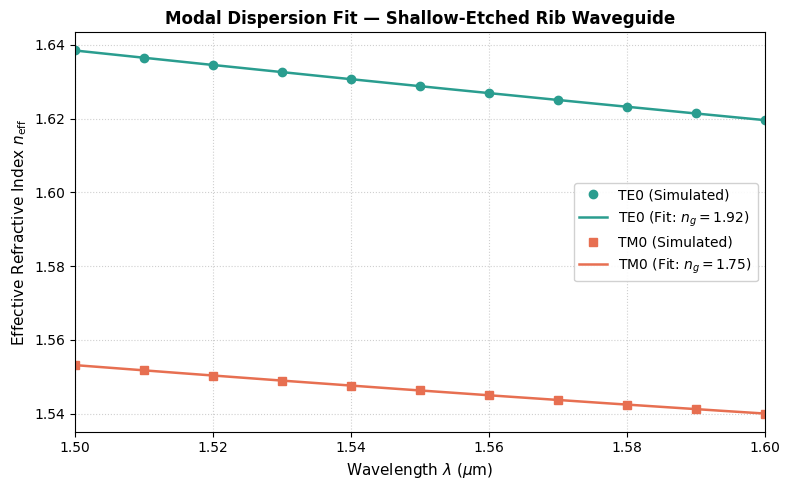

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import gplugins.tidy3d as gt

# Define physical scale if not already imported
nm = 1e-3  # Conversion factor to micrometers (µm)

# ==============================================================================
# 1. SIMULATION SETUP & GEOMETRICAL PARAMETERS
# ==============================================================================

wavelengths = np.linspace(1.5, 1.6, 11)  # Spectral sweep range (µm)
lambda_0 = 1.55                           # Central operating wavelength (µm)
c = 2.99792458e8                          # Speed of light in vacuum (m/s)

# Deep-etched strip waveguide (core: Si3N4, clad: SiO2)
deep_waveguide = gt.modes.Waveguide(
    core_width=1.2,                # Waveguide width (µm)
    core_thickness=300 * nm,       # Waveguide core height (µm)
    slab_thickness=0.0,            # Strip waveguide (no slab)
    core_material='sin',           # Silicon Nitride core
    clad_material='sio2',          # Silicon Dioxide cladding
    wavelength=wavelengths,       # Wavelength sweep array
    num_modes=2,                   # Find fundamental TE0 and TM0
    max_grid_scaling=1.5,
    grid_resolution=50,
    cache_path='.cache/',
    precision='double',
)

# Shallow-etched rib waveguide (core: Si3N4, clad: SiO2)
shallow_waveguide = gt.modes.Waveguide(
    core_width=1.2,                # Waveguide width (µm)
    core_thickness=300 * nm,       # Total core height (µm)
    slab_thickness=150 * nm,       # Residual slab height (µm)
    core_material='sin',           # Silicon Nitride core
    clad_material='sio2',          # Silicon Dioxide cladding
    wavelength=wavelengths,       # Wavelength sweep array
    num_modes=2,                   # Find fundamental TE0 and TM0
    max_grid_scaling=1.5,
    grid_resolution=50,
    cache_path='.cache/',
    precision='double',
)

# ==============================================================================
# 2. EXTRACT EFFECTIVE INDICES & POLYNOMIAL DISPERSION FITTING
# ==============================================================================

# Extract real parts of effective indices across the sweep
# Mode 0: fundamental TE (TE0), Mode 1: fundamental TM (TM0)
modes_config = [
    {
        "title": "Deep-Etched Strip Waveguide",
        "type": "deep",
        "modes": [
            {"name": "TE0", "neff_data": deep_waveguide.n_eff.real[:, 0], "color": "#1d3557", "marker": "o"},
            {"name": "TM0", "neff_data": deep_waveguide.n_eff.real[:, 1], "color": "#e63946", "marker": "s"},
        ],
    },
    {
        "title": "Shallow-Etched Rib Waveguide",
        "type": "shallow",
        "modes": [
            {"name": "TE0", "neff_data": shallow_waveguide.n_eff.real[:, 0], "color": "#2a9d8f", "marker": "o"},
            {"name": "TM0", "neff_data": shallow_waveguide.n_eff.real[:, 1], "color": "#e76f51", "marker": "s"},
        ],
    },
]

# Centered wavelength coordinate: Delta_lambda = lambda - lambda_0
X = wavelengths - lambda_0
X_dense = np.linspace(min(X), max(X), 200)
wvl_dense = X_dense + lambda_0

# Dense evaluation and plotting loop
for group in modes_config:
    plt.figure(figsize=(8, 5))
    print(f"\n=======================================================")
    print(f"  {group['title'].upper()}")
    print(f"=======================================================")

    for mode in group["modes"]:
        # Second-order polynomial fit: n_eff(X) = n3 * X^2 + n2 * X + n1
        # np.polyfit returns coefficients in descending order: [n3, n2, n1]
        coeffs = np.polyfit(X, mode["neff_data"], deg=2)
        n3, n2, n1 = coeffs[0], coeffs[1], coeffs[2]

        # Optical group index at lambda_0: n_g = n_eff(lambda_0) - lambda_0 * (dn_eff / dlambda)
        n_g = n1 - n2 * lambda_0

        # Chromatic dispersion parameter D = - (lambda / c) * (d^2 n_eff / dlambda^2)
        # Note: Converting lambda_0 from um to m, and n3 from um^-2 to m^-2 yields D in ps / (nm * km):
        # D [ps / (nm * km)] = - (2 * lambda_0 * n3 / c) * 1e6
        D_si = -(2.0 * (lambda_0 * 1e-6) * (n3 * 1e12)) / c  # s / m^2
        D_ps_nm_km = D_si * 1e6                              # ps / (nm * km)

        # Evaluated polynomial curve
        neff_fit = n1 + n2 * X_dense + n3 * (X_dense ** 2)

        print(f"[{mode['name']} Mode]")
        print(f"  n1 (n_eff at 1.55 µm) : {n1:.4f}")
        print(f"  n2 (dn_eff/dλ)        : {n2:.4f} µm⁻¹")
        print(f"  n3 (0.5 * d²n/dλ²)    : {n3:.4f} µm⁻²")
        print(f"  Group index (n_g)     : {n_g:.4f}")
        print(f"  Dispersion D (SI)     : {D_si:.3e} s/m²")
        print(f"  Dispersion D          : {D_ps_nm_km:.2f} ps/(nm·km)\n")

        # Plot discrete simulation points and smooth polynomial fit
        plt.plot(wavelengths, mode["neff_data"], linestyle='None', marker=mode["marker"],
                 color=mode["color"], markersize=6, label=f"{mode['name']} (Simulated)")
        plt.plot(wvl_dense, neff_fit, linestyle='-', color=mode["color"],
                 linewidth=1.8, label=f"{mode['name']} (Fit: $n_g={n_g:.2f}$)")

    plt.xlabel(r"Wavelength $\lambda$ ($\mu\mathrm{m}$)", fontsize=11)
    plt.ylabel(r"Effective Refractive Index $n_{\mathrm{eff}}$", fontsize=11)
    plt.title(f"Modal Dispersion Fit — {group['title']}", fontsize=12, weight='bold')
    plt.xlim(1.50, 1.60)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(frameon=True, facecolor='white', framealpha=0.9, loc='best')
    plt.tight_layout()
    plt.show()

## LO.4. Bend waveguide radius vs. loss – deep

The bend loss has three primary contributions:

1. Mode-mismatch loss
2. Radiation loss
3. Propagation loss

Vamos a ver el desajuste del modo en un bend

L = 2*pi*R / 4   # Se divide entre 4 porque vamos a tener en cuenta un cuarto de circunferencia para caracterizar el bend.

Perdidas de propagación alpha = [dB/cm]               

Loss = L[cm]*alpha[dB/cm]

Calculamos los modos de la guía recta y de la guía curva. Partimos de unas perdidas de propagación sacadas experimentalmente.

Perdidas de radiación se obtienen mediante simulaciones 3D como FDTD

En este caso se van a obviar las perdidas de radiación.

2026-03-03 16:28:56.736 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_1592dba1d8e935a8.npz.


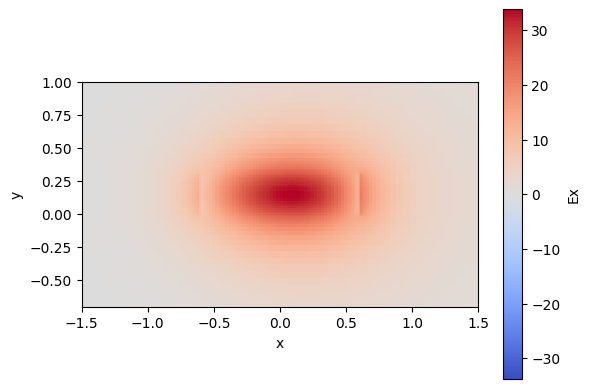

In [11]:
bend_1550 = gt.modes.Waveguide(
    wavelength=1550 * nm,
    core_width=1.2,
    slab_thickness=0.0,
    core_material='sin',
    clad_material='sio2',
    core_thickness=300 * nm,
    num_modes=1,
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.2,
    grid_resolution=30, 
    bend_radius=20, # Bend radius
)

bend_1550.plot_field(field_name="Ex", 
                     mode_index=0, # Field to be plotted
                     value='real', # Real - abs - imag
                     cmap='coolwarm',
                     xlim=(-1.5, 1.5), # Set the x and y limits
                     ylim=(-0.7, 1)) 

Va a tener un índice efectivo ligeramente distinto por el desplazamiento del modo dentro de la guía.

Hay un desajuste de modo.

### Mode-mismatch loss

Bend waveguide mode differs slightly from the straight waveguide mode, wich yield into mode-convertion losses. We can calculate this factor with as the overlap of the latter two modes. 

This is already implemented on GDSfactory library: 

Lo que hace es calcular el modo de la guía curva y hacer la integral de solape de la guía curva y la recta. Dando un porcentaje de modo que se solapa entre ambas.

  0%|          | 0/10 [00:00<?, ?it/s]

c:\Users\cfp\Desktop\Diseño_S\Repositories_diseño\pic-upv-lab1\.venv\Lib\site-packages\tidy3d\components\mode\derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
c:\Users\cfp\Desktop\Diseño_S\Repositories_diseño\pic-upv-lab1\.venv\Lib\site-packages\tidy3d\components\mode\derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
c:\Users\cfp\Desktop\Diseño_S\Repositor

Text(0, 0.5, 'Mismatch (dB)')

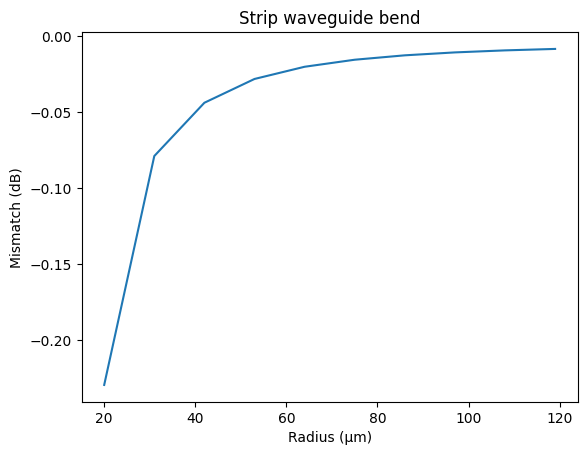

In [12]:
radii = np.arange(20.0, 120,11)

mismatch = gt.modes.sweep_bend_mismatch(bend_1550, radii)

plt.plot(radii, 10 * np.log10(mismatch))
plt.title("Strip waveguide bend")
plt.xlabel("Radius (μm)")
plt.ylabel("Mismatch (dB)")

El desajuste que obtenemos, por cada transición que haya de una guía curva a una recta cuanta energía de pierde. Esto es por cada cuarto de vuelta.

Por lo que podemos ver que a mayor radio tendremos menores pérdidas. No obstante, si queremos tener un footprint reducido, es mejor usar un radio menor a pesar de sus mayores pérdidas. 

También hay que tener en cuenta que a mayor radio, más larga es la guía y habrá mayores pérdidas de propagación, por lo que, como veremos más adelante, hay una relación de compromiso, la cual vamos a hallar.

### Propagation loss

Consider the equivalent linear length of the quarter-circle bend. Light will attenuate following a trend quantified with the experimentally measured parameter $$\alpha [\mathrm{dB}/\mathrm{cm}]$$. It depends on the fabrication process mainly. We will add this loss (in dBs) to the mode-mismatch loss to calculate the total loss per bend. 

*We are not considering the radiation losses, mainly because is not easy to implement a quick simulation for this parameter. Under certain conditions, the main loss sources are the ones considered in this example


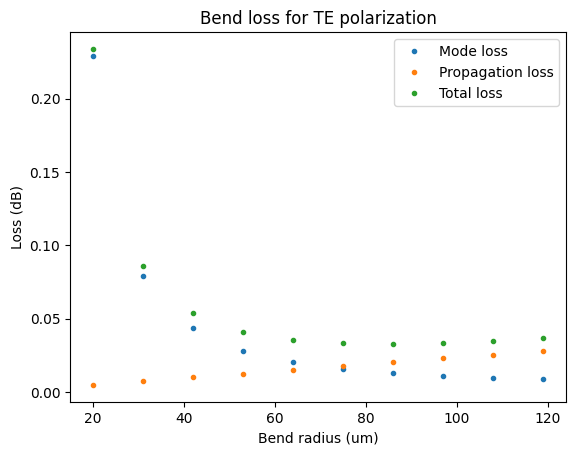

In [17]:
dB_cm = 1.5  # dB/cm Technology loss - 
length = 0.5 * np.pi * radii * 1e-6
propagation_loss = dB_cm * length * 1e2
propagation_loss

plt.title("Bend loss for TE polarization")
plt.plot(radii, -10 * np.log10(mismatch), ".", label="Mode loss")
plt.plot(radii, propagation_loss, ".", label="Propagation loss")
plt.plot(radii, propagation_loss-10 * np.log10(mismatch), ".", label="Total loss")
plt.xlabel("Bend radius (um)")
plt.ylabel("Loss (dB)")
plt.legend()

Podemos observar que para radios cortos dominan las pérdidas modales, mientras que a partir de entorno a las 75 um empezará a predominar las pérdidad de propagación.

- Use the code provided in this section to calculate the safe radius for 1.2 um width deep waveguides at 1.5 um. 

In [18]:
# Calcular el radio seguro para la guía de onda deep de 1.2 um de ancho a 1.55 um
# encontrando el radio que minimiza la pérdida total

total_loss = propagation_loss - 10 * np.log10(mismatch)

min_loss_idx = np.argmin(total_loss)
safe_radius = radii[min_loss_idx]
min_total_loss = total_loss[min_loss_idx]

print(f"Radio seguro para guía de onda deep de 1.2 μm de ancho a 1.55 μm: {safe_radius:.1f} μm")
print(f"Pérdida total mínima en el radio seguro: {min_total_loss:.4f} dB")

Radio seguro para guía de onda deep de 1.2 μm de ancho a 1.55 μm: 86.0 μm
Pérdida total mínima en el radio seguro: 0.0329 dB


Finalmente, el radio óptimo para el cual va a haber pérdidas totales mínimas será de entorno a 86 um, con unas pérdidas totales mínimas de 0.0329 dB.

### Ejercicio Learning outcome #4 – Bend waveguide radius vs. loss – deep

Calculando modos en curvas...
2026-03-03 17:36:03.290 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_1fae764bf0767424.npz.
Radio: 25 μm - neff TE0: 1.593697, neff TM0: 1.561671
2026-03-03 17:36:03.290 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_b9bdbd79392dcce5.npz.
Radio: 50 μm - neff TE0: 1.592373, neff TM0: 1.519517
2026-03-03 17:36:03.304 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_08a772776e70889d.npz.
Radio: 75 μm - neff TE0: 1.592190, neff TM0: 1.518458
2026-03-03 17:36:03.309 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_779c02d389de4a38.npz.
Radio: 100 μm - neff TE0: 1.592142, neff TM0: 1.518090
2026-03-03 17:36:03.314 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_2ff7e8d79f403ed2.npz.
Radio: 125 μm - neff TE0: 1.592127, neff TM0: 1.517919
2026-03-03 17:36:03.320 | INFO     | gplugins.tidy3d.modes:_data:266 - lo

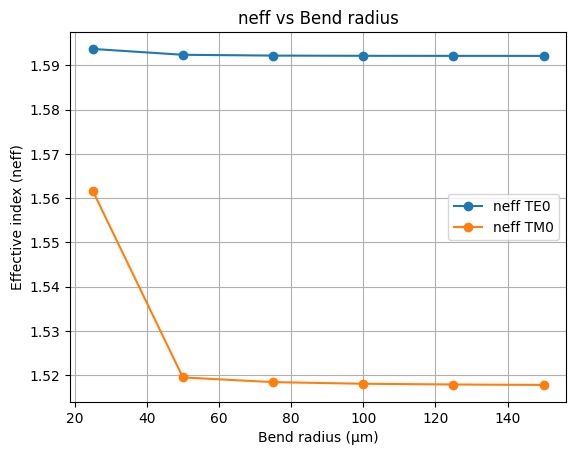

In [24]:
# Compute neff for TE0/TM0 and bend losses per 90° for width=1.0 um at 1.55 um
radii = np.array([25, 50, 75, 100, 125, 150])

# compute bent waveguide neff for TE0 and TM0 at each radius
neff_TE0 = []
neff_TM0 = []

print("Calculando modos en curvas...")

for r in radii:
    wb = gt.modes.Waveguide(
        wavelength=1550 * nm,
        core_width=1.0,
        slab_thickness=0.0,
        core_material='sin',
        clad_material='sio2',
        core_thickness=300 * nm,
        num_modes=2,                # Para hallar TE0 y TM0
        cache_path='.cache/',
        precision='double',
        max_grid_scaling=1.2,
        grid_resolution=30, 
        bend_radius=r,
    )

    neff_TE0.append(wb.n_eff.real[0])
    neff_TM0.append(wb.n_eff.real[1])

    print(f"Radio: {r} μm - neff TE0: {wb.n_eff.real[0]:.6f}, neff TM0: {wb.n_eff.real[1]:.6f}")

#Print neff vs radii

plt.plot(radii, neff_TE0, '-o', label='neff TE0')
plt.plot(radii, neff_TM0, '-o', label='neff TM0')
plt.grid()
plt.title('neff vs Bend radius')
plt.xlabel('Bend radius (μm)')
plt.ylabel('Effective index (neff)')
plt.legend()
plt.show()

  0%|          | 0/6 [00:00<?, ?it/s]

/home/andriusstb/pic-upv-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/andriusstb/pic-upv-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/andriusstb/pic-upv-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/

19:49:28 CEST WARNING: Mode field at frequency index 0, mode index 1 does not   
              decay at the plane boundaries.                                    

/home/andriusstb/pic-upv-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/andriusstb/pic-upv-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/andriusstb/pic-upv-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/

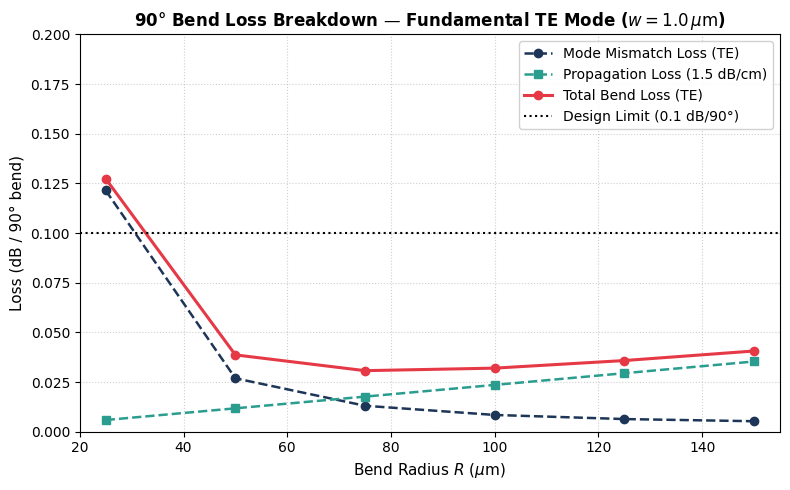

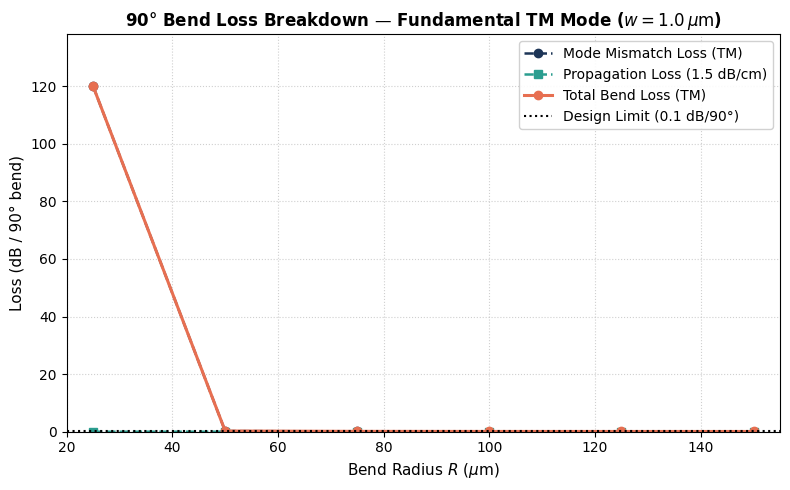

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import gplugins.tidy3d as gt

# Physical scale definition (micrometer baseline)
nm = 1e-3  # Conversion factor to µm

# ==============================================================================
# 1. WAVEGUIDE & BEND SWEEP CONFIGURATION
# ==============================================================================

# Sweep bend radii in micrometers
radii = np.array([25, 50, 75, 100, 125, 150], dtype=float)  # µm

# Silicon Nitride strip waveguide geometry at 1550 nm
bend_1550_slide = gt.modes.Waveguide(
    wavelength=1550 * nm,       # 1.55 µm operating wavelength
    core_width=1.0,             # Waveguide width (µm)
    core_thickness=300 * nm,    # Core thickness (µm)
    slab_thickness=0.0,         # Deep-etched strip profile
    core_material='sin',        # Silicon Nitride (Si3N4) core
    clad_material='sio2',       # Silicon Dioxide (SiO2) cladding
    num_modes=2,                # Fundamental TE0 and TM0
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.2,
    grid_resolution=30,
)

# Compute mode overlap mismatch between straight waveguide and bent modes
# mismatch[:, 0] -> Fundamental TE mode power transmission
# mismatch[:, 1] -> Fundamental TM mode power transmission
mismatch = gt.modes.sweep_bend_mismatch(bend_1550_slide, radii)

# ==============================================================================
# 2. LOSS CONTRIBUTIONS CALCULATION (90-DEGREE BENDS)
# ==============================================================================

alpha_dB_cm = 1.5  # Baseline linear propagation loss in dB/cm

# Physical arc length of a 90-degree circular bend: L = (pi / 2) * R
arc_length_um = 0.5 * np.pi * radii         # Length in µm
arc_length_cm = arc_length_um * 1e-4        # Convert µm to cm

# Propagation loss per 90-degree bend
propagation_loss = alpha_dB_cm * arc_length_cm  # dB / 90°

# Mode mismatch insertion loss: IL_mismatch = -10 * log10(eta)
loss_mismatch_TE = -10.0 * np.log10(np.maximum(mismatch[:, 0], 1e-12))
loss_mismatch_TM = -10.0 * np.log10(np.maximum(mismatch[:, 1], 1e-12))

# Total insertion loss per 90-degree bend
total_loss_TE = propagation_loss + loss_mismatch_TE
total_loss_TM = propagation_loss + loss_mismatch_TM

loss_budget_limit = 0.1  # Typical PIC design threshold (0.1 dB / 90°)

# ==============================================================================
# 3. VISUALIZATION (TECHNICAL PLOTS)
# ==============================================================================

# --- Figure 1: Fundamental Quasi-TE Mode ---
plt.figure(figsize=(8, 5))
plt.plot(radii, loss_mismatch_TE, "o--", color="#1d3557", lw=1.8, label="Mode Mismatch Loss (TE)")
plt.plot(radii, propagation_loss, "s--", color="#2a9d8f", lw=1.8, label=f"Propagation Loss ({alpha_dB_cm} dB/cm)")
plt.plot(radii, total_loss_TE, "o-", color="#e63946", lw=2.2, label="Total Bend Loss (TE)")
plt.axhline(y=loss_budget_limit, color="black", linestyle=":", lw=1.5, label=f"Design Limit ({loss_budget_limit} dB/90°)")

plt.title(r"90° Bend Loss Breakdown — Fundamental TE Mode ($w = 1.0\,\mu\mathrm{m}$)", fontsize=12, weight='bold')
plt.xlabel(r"Bend Radius $R$ ($\mu\mathrm{m}$)", fontsize=11)
plt.ylabel(r"Loss (dB / 90° bend)", fontsize=11)
plt.xlim(20, 155)
plt.ylim(0, max(np.max(total_loss_TE) * 1.15, 0.2))
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(frameon=True, facecolor="white", framealpha=0.9, loc="upper right")
plt.tight_layout()
plt.show()

# --- Figure 2: Fundamental Quasi-TM Mode ---
plt.figure(figsize=(8, 5))
plt.plot(radii, loss_mismatch_TM, "o--", color="#1d3557", lw=1.8, label="Mode Mismatch Loss (TM)")
plt.plot(radii, propagation_loss, "s--", color="#2a9d8f", lw=1.8, label=f"Propagation Loss ({alpha_dB_cm} dB/cm)")
plt.plot(radii, total_loss_TM, "o-", color="#e76f51", lw=2.2, label="Total Bend Loss (TM)")
plt.axhline(y=loss_budget_limit, color="black", linestyle=":", lw=1.5, label=f"Design Limit ({loss_budget_limit} dB/90°)")

plt.title(r"90° Bend Loss Breakdown — Fundamental TM Mode ($w = 1.0\,\mu\mathrm{m}$)", fontsize=12, weight='bold')
plt.xlabel(r"Bend Radius $R$ ($\mu\mathrm{m}$)", fontsize=11)
plt.ylabel(r"Loss (dB / 90° bend)", fontsize=11)
plt.xlim(20, 155)
plt.ylim(0, max(np.max(total_loss_TM) * 1.15, 0.2))
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(frameon=True, facecolor="white", framealpha=0.9, loc="upper right")
plt.tight_layout()
plt.show()

## EXTRA

All the past simulations were done considering as core material de Silicon Nitride (SiNx) and Silicon Dioxide (SiO2) as cladding material. Now, **simulate the Silicon-On-Insulator technology changing the core material to Silicon (Si)**. In this case, the dimensions will be 220 nm heigth and 500 nm width. 
1. Repeat the LO.1. wavelength behavior simulations, considering the updated materials and dimensions. 
2. Repeat the LO.2. width dependence analysis, now sweeping in a 300nm - 1um range. 
3. Find the safe radius for this technology. Consider sweeping the radius in a 5um to 30um range. 
4. **Compare the SiNx and SOI technologies** 

## Grading

LO.1. 2 Point <br> 
LO.2. 1 Points <br> 
LO.3. 3 Point <br> 
LO.4. 1 Points <br> 
**Total 7 Points** <br>
Extra (Up to) 3 Points


2. Encontrar el corte para esta nueva guía ?

4. **Compare the SiNx and SOI technologies** 
Cuales son los índices ejectivos, los diferentes radios de curvatura

2026-03-04 10:54:00.169 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_9b607c2ee0ef414d.npz.


array([2.44861457, 1.79072971, 1.50655788, 1.43326339])

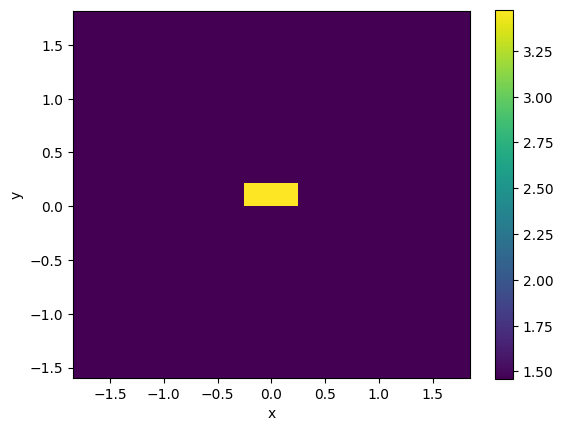

In [4]:
deep_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=0.5, # Waveguide width
    core_thickness=220 * nm, # Waveguide height 
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    # Materials
    core_material='si', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=1550 * nm, # Wavelength to simulate
    num_modes=4, # Targeted number of modes to find 
    max_grid_scaling=1.5, # Parameters of the grid 
    grid_resolution=20, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
)

deep_waveguide.plot_index()

deep_waveguide.n_eff.real

# Student continue your code here ...

2026-03-04 10:54:00.962 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_555496046cbcf8ad.npz.
2026-03-04 10:54:00.984 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_9b607c2ee0ef414d.npz.
2026-03-04 10:54:00.988 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_0866d3aa55a99d6e.npz.
2026-03-04 10:54:01.010 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_b6d52bd5523d441b.npz.
2026-03-04 10:54:01.028 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_2e7d1521ebf07a15.npz.
2026-03-04 10:54:01.057 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_ba0e1285093a72b6.npz.
2026-03-04 10:54:01.077 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_3700896b1b09c109.npz.
2026-03-04 10:54:01.098 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_85555abca54fa391.npz.


Text(0, 0.5, 'Effective index')

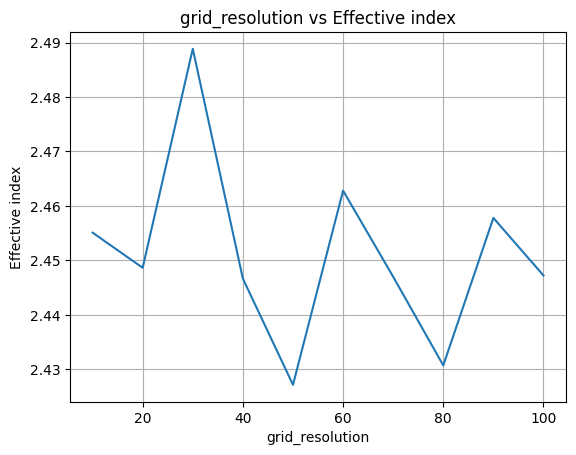

In [5]:
grid_resolution_list = np.linspace(10, 100, 10)
index_list = []
for i in grid_resolution_list:

    deep_waveguide = gt.modes.Waveguide(
        # Geometrical Parameters
        core_width=0.5, # Waveguide width
        core_thickness=220 * nm, # Waveguide height 
        slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
        # Materials
        core_material='si', #  Material of the waveguide
        clad_material='sio2', # Surrounding material
        # Modesolver Parameters
        wavelength=1550 * nm, # Wavelength to simulate
        num_modes=4, # Targeted number of modes to find 
        max_grid_scaling=1.5, # Parameters of the grid 
        grid_resolution= i, # Parameters of the grid
        cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
        precision='double',
    )

    index_list.append(deep_waveguide.n_eff.real[0])

index_list = np.array(index_list)

plt.plot(grid_resolution_list, index_list)
plt.grid()
plt.title('grid_resolution vs Effective index')
plt.xlabel('grid_resolution')
plt.ylabel('Effective index')

2026-03-04 11:07:08.369 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_223d93916735b32f.npz.
2026-03-04 11:07:08.374 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_2b23fbc3e6bc4a22.npz.
2026-03-04 11:07:08.374 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_d2a12d2520042e19.npz.
2026-03-04 11:07:08.385 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_9b607c2ee0ef414d.npz.
2026-03-04 11:07:08.388 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_02d6f234e1cf89a5.npz.


Text(0, 0.5, 'Effective index')

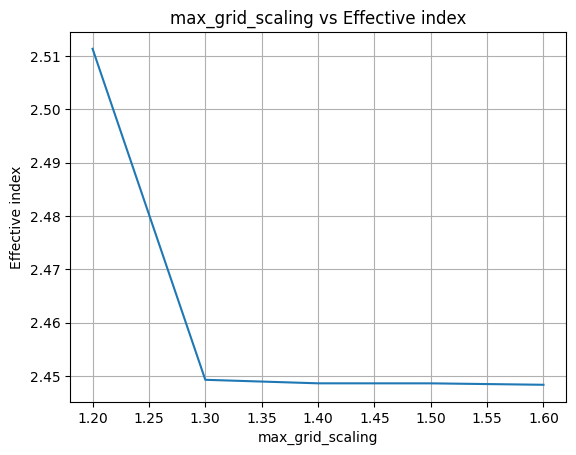

In [12]:
max_grid_scaling_list = np.linspace(1.2, 1.6, 5)
index_list = []
for i in max_grid_scaling_list:

    deep_waveguide = gt.modes.Waveguide(
        # Geometrical Parameters
        core_width=0.5, # Waveguide width
        core_thickness=220 * nm, # Waveguide height 
        slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
        # Materials
        core_material='si', #  Material of the waveguide
        clad_material='sio2', # Surrounding material
        # Modesolver Parameters
        wavelength=1550 * nm, # Wavelength to simulate
        num_modes=4, # Targeted number of modes to find 
        max_grid_scaling=i, # Parameters of the grid 
        grid_resolution= 20, # Parameters of the grid
        cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
        precision='double',
    )

    index_list.append(deep_waveguide.n_eff.real[0])

index_list = np.array(index_list)

plt.plot(max_grid_scaling_list, index_list)
plt.grid()
plt.title('max_grid_scaling vs Effective index')
plt.xlabel('max_grid_scaling')
plt.ylabel('Effective index')

  0%|          | 0/11 [00:00<?, ?it/s]

2026-03-04 11:46:07.529 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_9fd1473f015a7c34.npz.
2026-03-04 11:46:07.532 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_b50fbd805c54a889.npz.
2026-03-04 11:46:07.536 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_2b3bc7afa064ee32.npz.
2026-03-04 11:46:07.539 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_99d2f3bf4f372f5f.npz.
2026-03-04 11:46:07.541 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_2f022f35a96932ee.npz.
2026-03-04 11:46:07.541 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_4064116875f0080b.npz.
2026-03-04 11:46:07.555 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_d291f0a5505be8cb.npz.
2026-03-04 11:46:07.556 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_44939e121b253cd1.npz.


  0%|          | 0/11 [00:00<?, ?it/s]

2026-03-04 11:46:07.604 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_9fd1473f015a7c34.npz.
2026-03-04 11:46:07.630 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_b50fbd805c54a889.npz.
2026-03-04 11:46:07.641 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_2b3bc7afa064ee32.npz.
2026-03-04 11:46:07.648 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_99d2f3bf4f372f5f.npz.
2026-03-04 11:46:07.652 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_2f022f35a96932ee.npz.
2026-03-04 11:46:07.657 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_4064116875f0080b.npz.
2026-03-04 11:46:07.661 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_d291f0a5505be8cb.npz.
2026-03-04 11:46:07.665 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_44939e121b253cd1.npz.


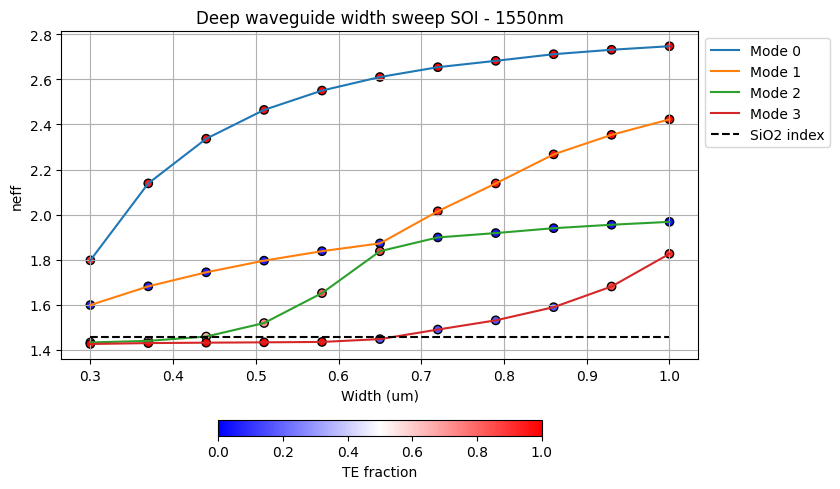

In [18]:
wavelength = 1.55 # Student code here

deep_waveguide = gt.modes.Waveguide(
    wavelength=wavelength,
    core_width=0.5,
    core_material='si',
    clad_material='sio2',
    core_thickness=220 * nm,
    slab_thickness=0 * nm,
    num_modes=4,
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.3,
    grid_resolution=20, 
)

w = np.linspace(0.3, 1, 11) # Student code here

sweep_neff = gt.modes.sweep_n_eff(deep_waveguide, 
                             core_width=w)

sweep_tefraction = gt.modes.sweep_fraction_te(deep_waveguide,
                                              core_width=w)

plt.figure(figsize=(10, 5))
for k in range(sweep_neff.shape[1]):
    plt.scatter(w, sweep_neff[:,k].real,edgecolors='k',c=sweep_tefraction.sel(mode_index=k),vmin=0, vmax=1,label = '__nolegend__',cmap='bwr')
    plt.plot(w, sweep_neff[:,k].real,label=f'Mode {k}')

plt.title("Deep waveguide width sweep SOI - 1550nm")
plt.xlabel("Width (um)")
plt.ylabel("neff")
plt.grid()
plt.hlines(np.mean(box_index), xmin=np.min(w), xmax=np.max(w), colors='k', linestyles='dashed',label='SiO2 index')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.colorbar(orientation='horizontal',fraction=0.04).set_label("TE fraction")

## LO.4. Bend waveguide radius vs. loss – deep

2026-03-04 11:09:35.498 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_390f8f4e59dd7ef6.npz.


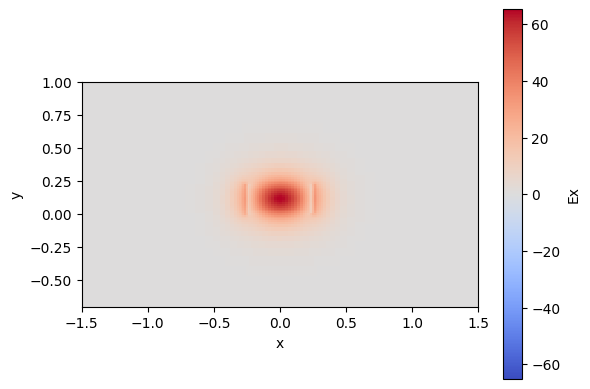

In [14]:
bend_1550 = gt.modes.Waveguide(
    wavelength=1550 * nm,
    core_width=0.5,
    slab_thickness=0.0,
    core_material='si',
    clad_material='sio2',
    core_thickness=220 * nm,
    num_modes=1,
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.3,
    grid_resolution=20, 
    bend_radius=20, # Bend radius
)

bend_1550.plot_field(field_name="Ex", 
                     mode_index=0, # Field to be plotted
                     value='real', # Real - abs - imag
                     cmap='coolwarm',
                     xlim=(-1.5, 1.5), # Set the x and y limits
                     ylim=(-0.7, 1)) 

Calculando modos en curvas...
2026-03-04 11:51:13.280 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_0a95e3c59a3ed874.npz.
Radio: 5 μm - neff TE0: 2.476910, neff TM0: 1.964426
2026-03-04 11:51:13.280 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_77083beb541ea22f.npz.
Radio: 10 μm - neff TE0: 2.477718, neff TM0: 1.833944
2026-03-04 11:51:13.297 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_5b6ccd2ae83bbb84.npz.
Radio: 15 μm - neff TE0: 2.478149, neff TM0: 1.832838
2026-03-04 11:51:13.297 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_5c034fb4d670288c.npz.
Radio: 20 μm - neff TE0: 2.478396, neff TM0: 1.832430
2026-03-04 11:51:13.297 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_de1be116710ca0b2.npz.
Radio: 25 μm - neff TE0: 2.478554, neff TM0: 1.832230
2026-03-04 11:51:13.313 | INFO     | gplugins.tidy3d.modes:_data:266 - load 

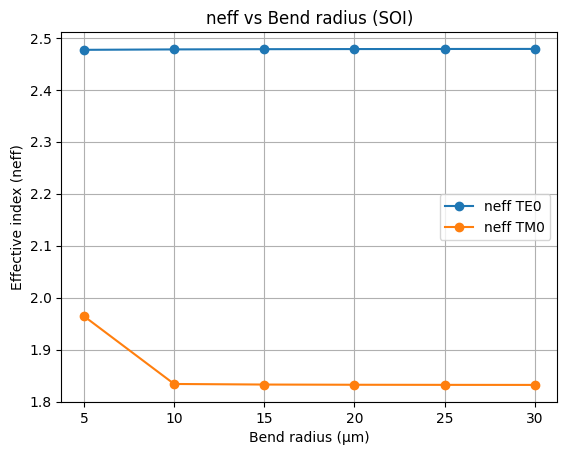

In [20]:
radii = np.array([5,10,15,20,25,30])

# compute bent waveguide neff for TE0 and TM0 at each radius
neff_TE0 = []
neff_TM0 = []

print("Calculando modos en curvas...")

for r in radii:
    wb = gt.modes.Waveguide(
        wavelength=1550 * nm,
        core_width=0.5,
        slab_thickness=0.0,
        core_material='si',
        clad_material='sio2',
        core_thickness=220 * nm,
        num_modes=2,                # Para hallar TE0 y TM0
        cache_path='.cache/',
        precision='double',
        max_grid_scaling=1.2,
        grid_resolution=30, 
        bend_radius=r,
    )

    neff_TE0.append(wb.n_eff.real[0])
    neff_TM0.append(wb.n_eff.real[1])

    print(f"Radio: {r} μm - neff TE0: {wb.n_eff.real[0]:.6f}, neff TM0: {wb.n_eff.real[1]:.6f}")

#Print neff vs radii

plt.plot(radii, neff_TE0, '-o', label='neff TE0')
plt.plot(radii, neff_TM0, '-o', label='neff TM0')
plt.grid()
plt.title('neff vs Bend radius (SOI)')
plt.xlabel('Bend radius (μm)')
plt.ylabel('Effective index (neff)')
plt.legend()
plt.show()

  0%|          | 0/6 [00:00<?, ?it/s]

/home/andriusstb/pic-upv-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/andriusstb/pic-upv-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/andriusstb/pic-upv-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/

19:52:15 CEST WARNING: Mode field at frequency index 0, mode index 1 does not   
              decay at the plane boundaries.                                    

/home/andriusstb/pic-upv-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/andriusstb/pic-upv-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/andriusstb/pic-upv-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/

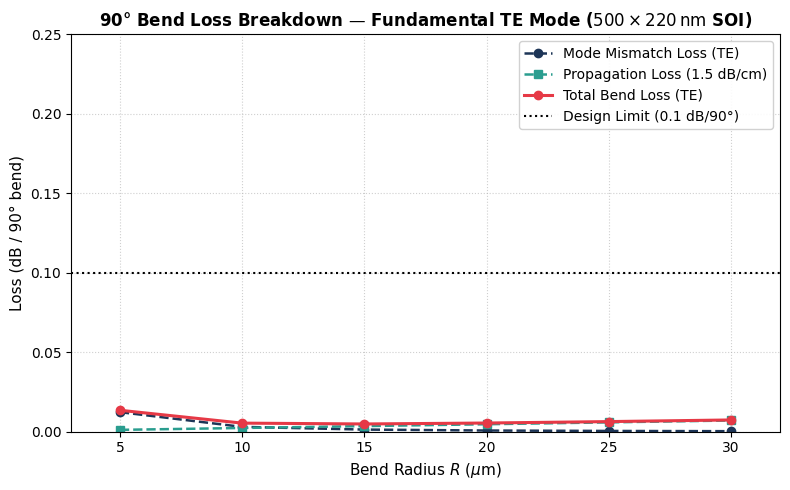

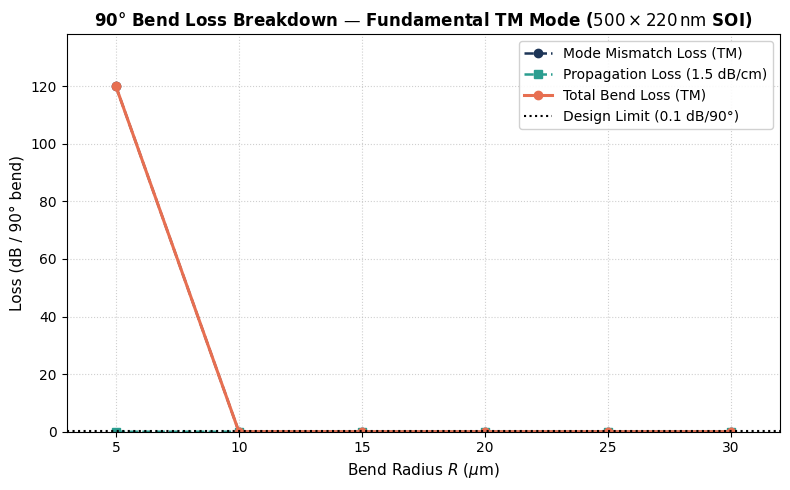

In [5]:
# Physical scale definition (micrometer baseline)
nm = 1e-3  # Conversion factor to µm

# ==============================================================================
# 1. SOI WAVEGUIDE & BEND SWEEP CONFIGURATION
# ==============================================================================

# Sweep bend radii in micrometers (sub-micron SOI enables tight bends)
radii = np.array([5, 10, 15, 20, 25, 30], dtype=float)  # µm

# Standard Silicon-on-Insulator (SOI) strip waveguide geometry at 1550 nm
bend_1550_slide = gt.modes.Waveguide(
    wavelength=1550 * nm,       # 1.55 µm central wavelength
    core_width=0.5,             # 500 nm strip waveguide width (µm)
    core_thickness=220 * nm,    # 220 nm standard SOI core height (µm)
    slab_thickness=0.0,         # Fully-etched strip profile
    core_material='si',         # Silicon (Si) core (n ≈ 3.47)
    clad_material='sio2',       # Silicon Dioxide (SiO2) cladding (n ≈ 1.44)
    num_modes=2,                # Fundamental TE0 and TM0
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.2,
    grid_resolution=30,
)

# Compute straight-to-bend modal overlap transmission
# mismatch[:, 0] -> Fundamental TE mode power transmission
# mismatch[:, 1] -> Fundamental TM mode power transmission
mismatch = gt.modes.sweep_bend_mismatch(bend_1550_slide, radii)

# ==============================================================================
# 2. LOSS CONTRIBUTIONS CALCULATION (90-DEGREE BENDS)
# ==============================================================================

alpha_dB_cm = 1.5  # Baseline linear propagation loss in dB/cm

# Physical arc length of a 90-degree circular bend: L = (pi / 2) * R
arc_length_um = 0.5 * np.pi * radii         # Length in µm
arc_length_cm = arc_length_um * 1e-4        # Convert µm to cm

# Propagation loss per 90-degree bend
propagation_loss = alpha_dB_cm * arc_length_cm  # dB / 90°

# Mode mismatch insertion loss: IL_mismatch = -10 * log10(eta)
loss_mismatch_TE = -10.0 * np.log10(np.maximum(mismatch[:, 0], 1e-12))
loss_mismatch_TM = -10.0 * np.log10(np.maximum(mismatch[:, 1], 1e-12))

# Total insertion loss per 90-degree bend
total_loss_TE = propagation_loss + loss_mismatch_TE
total_loss_TM = propagation_loss + loss_mismatch_TM

loss_budget_limit = 0.1  # Design threshold (0.1 dB / 90° bend)

# ==============================================================================
# 3. VISUALIZATION (TECHNICAL PLOTS)
# ==============================================================================

# --- Figure 1: Fundamental Quasi-TE Mode (SOI) ---
plt.figure(figsize=(8, 5))
plt.plot(radii, loss_mismatch_TE, "o--", color="#1d3557", lw=1.8, label="Mode Mismatch Loss (TE)")
plt.plot(radii, propagation_loss, "s--", color="#2a9d8f", lw=1.8, label=f"Propagation Loss ({alpha_dB_cm} dB/cm)")
plt.plot(radii, total_loss_TE, "o-", color="#e63946", lw=2.2, label="Total Bend Loss (TE)")
plt.axhline(y=loss_budget_limit, color="black", linestyle=":", lw=1.5, label=f"Design Limit ({loss_budget_limit} dB/90°)")

plt.title(r"90° Bend Loss Breakdown — Fundamental TE Mode ($500 \times 220\,\mathrm{nm}$ SOI)", fontsize=12, weight='bold')
plt.xlabel(r"Bend Radius $R$ ($\mu\mathrm{m}$)", fontsize=11)
plt.ylabel(r"Loss (dB / 90° bend)", fontsize=11)
plt.xlim(3, 32)
plt.ylim(0, max(np.max(total_loss_TE) * 1.15, 0.25))
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(frameon=True, facecolor="white", framealpha=0.9, loc="upper right")
plt.tight_layout()
plt.show()

# --- Figure 2: Fundamental Quasi-TM Mode (SOI) ---
plt.figure(figsize=(8, 5))
plt.plot(radii, loss_mismatch_TM, "o--", color="#1d3557", lw=1.8, label="Mode Mismatch Loss (TM)")
plt.plot(radii, propagation_loss, "s--", color="#2a9d8f", lw=1.8, label=f"Propagation Loss ({alpha_dB_cm} dB/cm)")
plt.plot(radii, total_loss_TM, "o-", color="#e76f51", lw=2.2, label="Total Bend Loss (TM)")
plt.axhline(y=loss_budget_limit, color="black", linestyle=":", lw=1.5, label=f"Design Limit ({loss_budget_limit} dB/90°)")

plt.title(r"90° Bend Loss Breakdown — Fundamental TM Mode ($500 \times 220\,\mathrm{nm}$ SOI)", fontsize=12, weight='bold')
plt.xlabel(r"Bend Radius $R$ ($\mu\mathrm{m}$)", fontsize=11)
plt.ylabel(r"Loss (dB / 90° bend)", fontsize=11)
plt.xlim(3, 32)
plt.ylim(0, max(np.max(total_loss_TM) * 1.15, 0.25))
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(frameon=True, facecolor="white", framealpha=0.9, loc="upper right")
plt.tight_layout()
plt.show()